In [55]:
import numpy as np
import matplotlib.pyplot as plt

# Task 1

In [57]:
def simulate_a_woman(X0,P): 
    states = np.array([0,1,2,3,4])
    States = []
    current_state =X0

    while current_state !=4:
        current_state = np.random.choice(states, p=P[current_state])
        States.append(current_state)
    return np.array(States)

In [58]:
# Task 1
P = np.array([
    [0.9915, 0.0050, 0.0025, 0.0000, 0.0010],
    [0.0000, 0.9860, 0.0050, 0.0040, 0.0050],
    [0.0000, 0.0000, 0.9920, 0.0030, 0.0050],
    [0.0000, 0.0000, 0.0000, 0.9910, 0.0090],
    [0.0000, 0.0000, 0.0000, 0.0000, 1.0000]
])

Lifetime = []
Women_with_local_cancer = 0
np.random.seed(42)
for i in range(1000):
    X = simulate_a_woman(0,P)
    Lifetime.append(len(X))
    if 1 in X:
        Women_with_local_cancer+=1
    elif 3 in X:
        Women_with_local_cancer+=1




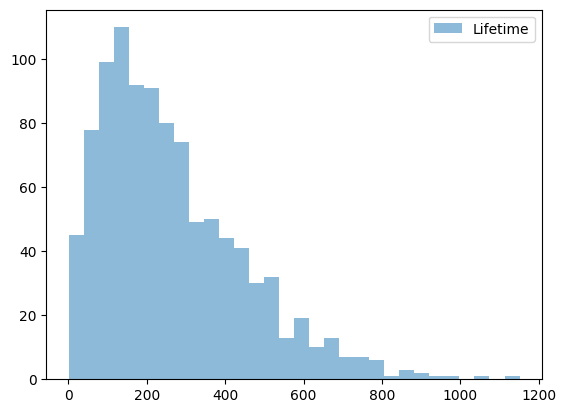

In [61]:
plt.hist(Lifetime, bins=30, alpha=0.5, label="Lifetime")

plt.legend()
plt.show()

In [62]:
Women_with_local_cancer/1000

0.712

# Task 2

In [64]:
P = np.array([
    [0.9915, 0.0050, 0.0025, 0.0000, 0.0010],
    [0.0000, 0.9860, 0.0050, 0.0040, 0.0050],
    [0.0000, 0.0000, 0.9920, 0.0030, 0.0050],
    [0.0000, 0.0000, 0.0000, 0.9910, 0.0090],
    [0.0000, 0.0000, 0.0000, 0.0000, 1.0000]
])
p0 = np.array([1000,0,0,0,0])
p=p0
for t in range(120):
    p = p@P
    if p[-1]>=999.5:
        break


In [66]:
# Theoretical distributtion at time 120
p

array([359.02626821, 158.95603979, 166.08689731,  67.74149395,
       248.18930075])

In [69]:
State_at_120 = []
np.random.seed(42)
for i in range(1000):
    X = simulate_a_woman(0,P)
    if len(X)>=120:
        State_at_120.append(X[119])
    else: 
        State_at_120.append(4)

In [70]:
# We do chi_square to test if distribution is the same
from scipy.stats import chisquare
observed_120 =  np.bincount(State_at_120)
chi2_stat, p_value = chisquare(
    f_obs=observed_120,
    f_exp=p
)

In [71]:
p_value

0.9055179937377961

In [112]:
pi = np.array([1,0,0,0])
Ps = np.array([
    [0.9915, 0.0050, 0.0025, 0.0000],
    [0.0000, 0.9860, 0.0050, 0.0040],
    [0.0000, 0.0000, 0.9920, 0.0030],
    [0.0000, 0.0000, 0.0000, 0.9910],
])
ps = np.array([0.0010,0.005,0.005,0.009])

Theoretical_number = []
T = []
for t in range(1,np.max(Lifetime)+1):
    T.append(t)
    prop = pi@np.linalg.matrix_power(Ps, t)@ps
    Theoretical_number.append(prop)
    


In [113]:
sum(Theoretical_number)

0.9975756805240262

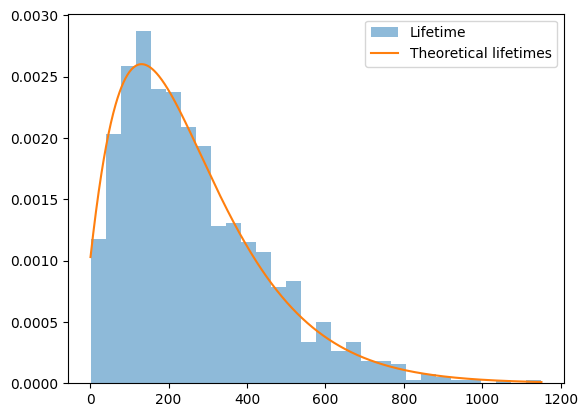

In [114]:
plt.hist(Lifetime, bins=30, alpha=0.5, label="Lifetime",density=True)
plt.plot(T,Theoretical_number,label = "Theoretical lifetimes")

plt.legend()
plt.show()

# Task 4

In [126]:
Women = []
np.random.seed(42)
while len(Women)!=1000:
    X = simulate_a_woman(0,P)
    if (1 in X[:12]) and (len(X)>12):
        Women.append(X) 

    elif (2 in X[:12]) and (len(X)>12):
        Women.append(X) 


In [128]:
Lifetimes_task4 =[]
for woman in Women:
    Lifetimes_task4.append(len(woman))

In [129]:
np.mean(Lifetimes_task4)

178.715

In [130]:
np.mean(Lifetime)

265.035

# Task 5

In [133]:
def Crude_monte_carlo(n):
    fractions = []
    for _ in range(n):
        frac = 0
        for i in range(200):
            X = simulate_a_woman(0,P)
            if len(X)<350:
                frac+=1
        frac = frac/200
        fractions.append(frac)
    return np.mean(fractions)
    

In [134]:
np.random.seed(42)
Crude_monte_carlo(100)

0.73645